In [2]:
import numpy as np
from scipy.integrate import quad
from scipy.linalg import solve

def u_i(x, i):
    if i == 1: return x*(1-x)
    elif i == 2: return x**2*(1-x)
    elif i == 3: return x**3*(1-x)

def du_i(x, i):
    if i == 1: return 1 - 2*x
    elif i == 2: return 2*x - 3*x**2
    elif i == 3: return 3*x**2 - 4*x**3

def ddu_i(x, i):
    if i == 1: return -2
    elif i == 2: return 2 - 6*x
    elif i == 3: return 6*x - 12*x**2

# x²/2 (удовлетворяет u'(1)=1)
def f(x):
    return x**2/2

def df(x):
    return x

def ddf(x):
    return 1

def compute_a(i, j):
    integrand = lambda x: (ddu_i(x,j) - 2*x*du_i(x,j) + 2*u_i(x,j)) * u_i(x,i)
    return quad(integrand, 0, 1)[0]

def compute_b(i):
    integrand = lambda x: (x - (ddf(x) - 2*x*df(x) + 2*f(x))) * u_i(x,i)
    return quad(integrand, 0, 1)[0]

# Построение и решение системы
A = np.zeros((3,3))
b = np.zeros(3)

for i in range(3):
    for j in range(3):
        A[i,j] = compute_a(i+1, j+1)
    b[i] = compute_b(i+1)

c = solve(A, b)

print(f"Коэффициенты:\nc1 = {c[0]:.4f}\nc2 = {c[1]:.4f}\nc3 = {c[2]:.4f}")
print(f"Проверка граничного условия u'(1) = {1 + du_i(1,1)*c[0] + du_i(1,2)*c[1] + du_i(1,3)*c[2]:.6f}")

Коэффициенты:
c1 = 0.2870
c2 = -0.1613
c3 = -0.1339
Проверка граничного условия u'(1) = 1.008261


n_steps = 2, u(1) = 1.000000, h = 1.0000
n_steps = 3, u(1) = 0.833333, h = 0.5000
n_steps = 4, u(1) = 0.744048, h = 0.3333
n_steps = 5, u(1) = 0.691209, h = 0.2500
n_steps = 10, u(1) = 0.587192, h = 0.1111
n_steps = 100, u(1) = 0.495118, h = 0.0101
n_steps = 1000, u(1) = 0.485976, h = 0.0010


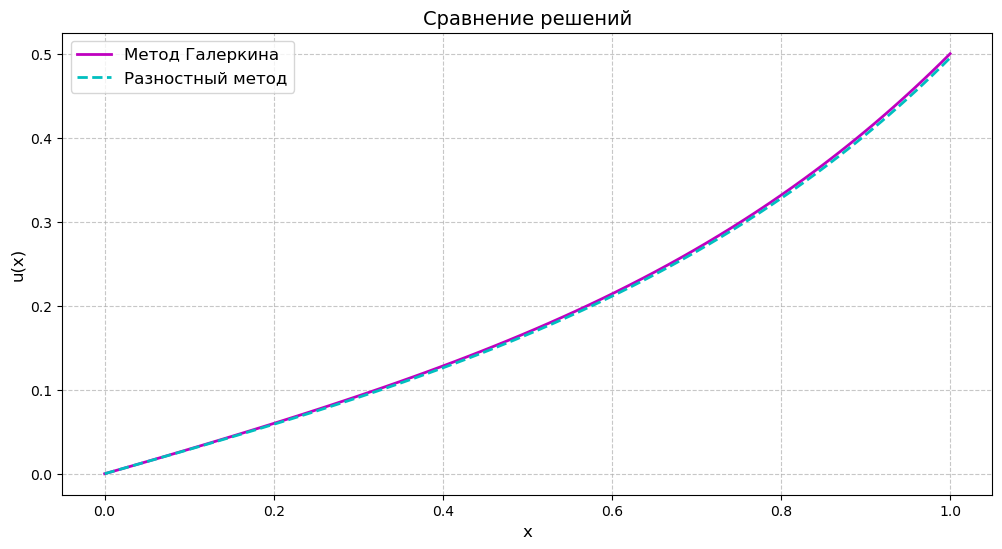

Максимальное расхождение: 4.89e-03


In [6]:
import numpy as np
import matplotlib.pyplot as plt

def finite_difference_solution(start=0, end=1, n_steps=100):
    h = (end - start) / (n_steps - 1)
    x = np.linspace(0, 1, n_steps)  # Узлы сетки
    
    # Инициализация матрицы
    A = np.zeros(n_steps)
    B = np.zeros(n_steps)
    C = np.zeros(n_steps)
    F = np.zeros(n_steps)
    
    # Внутренние узлы
    for i in range(1, n_steps-1):
        A[i] = 1/h**2 + x[i]/h
        B[i] = -2/h**2 + 2
        C[i] = 1/h**2 - x[i]/h
        F[i] = x[i]
    
    # Граничные условия
    B[0] = 1  # u(0) = 0
    F[0] = start

    A[-1] = -1  # u'(1) = 1
    B[-1] = 1
    F[-1] = h

    # Метод прогонки
    alpha = np.zeros(n_steps)
    beta = np.zeros(n_steps)
    u = np.zeros(n_steps)
    
    alpha[1] = -C[0]/B[0]
    beta[1] = F[0]/B[0]
    
    for i in range(1, n_steps-1):
        alpha[i+1] = -C[i]/(A[i]*alpha[i] + B[i])
        beta[i+1] = (F[i] - A[i]*beta[i])/(A[i]*alpha[i] + B[i])
    
    u[-1] = (F[-1] - A[-1]*beta[-1])/(B[-1] + A[-1]*alpha[-1])
    # print(alpha[-1], beta[-1], u[-1], h)
    
    for i in range(n_steps-2, -1, -1):
        u[i] = alpha[i+1]*u[i+1] + beta[i+1]
    
    return x, u

x_fd, u_fd = finite_difference_solution(n_steps=100)

for n_steps in [2, 3, 4, 5, 10, 100, 1000]:
    x, u = finite_difference_solution(n_steps=n_steps)
    print(f"n_steps = {n_steps}, u(1) = {u[-1]:.6f}, h = {1/(n_steps-1):.4f}")
# Решение методом Галеркина
def u_approx(x):
    return c[0]*u_i(x,1) + c[1]*u_i(x,2) + c[2]*u_i(x,3) + (x**2)/2
x_gal = np.linspace(0, 1, 100)
u_gal = [u_approx(x) for x in x_gal]


plt.figure(figsize=(12, 6))
plt.plot(x_gal, u_gal, 'm', label='Метод Галеркина', linewidth=2)
plt.plot(x_fd, u_fd, 'c--', label='Разностный метод', linewidth=2)
plt.xlabel('x', fontsize=12)
plt.ylabel('u(x)', fontsize=12)
plt.title('Сравнение решений', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=12)
plt.show()

diff = np.abs(u_gal - u_fd)
print(f"Максимальное расхождение: {np.max(diff):.2e}")